<a href="https://colab.research.google.com/github/AndrewOspina/INFO-465-The-A-Team/blob/main/predictivedemandmodel_INFO465_ATeam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Prepared Monthly Demand Data
----------------------------------------
  year_month   model dealer_region body_style transmission       color  \
0 2022-01-01  3000GT        Austin      Sedan       Manual  Pale White   
1 2022-01-01  3000GT    Middletown      Sedan         Auto       Black   
2 2022-01-01    300M        Austin        SUV         Auto       Black   
3 2022-01-01    300M         Pasco        SUV         Auto  Pale White   
4 2022-01-01    323i        Aurora  Hatchback         Auto  Pale White   

   demand  avg_price  total_revenue  year  month  quarter  is_year_end  \
0       1    20000.0          20000  2022      1        1            0   
1       1    39000.0          39000  2022      1        1            0   
2       1    26000.0          26000  2022      1        1            0   
3       2    19000.0          38000  2022      1        1            0   
4       1    15500.0          15500  2022      1        1            0   

   is_summer  lag_1_demand  lag_2_deman

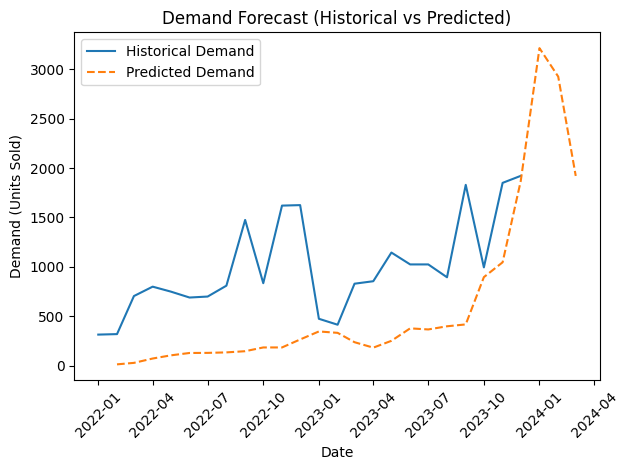

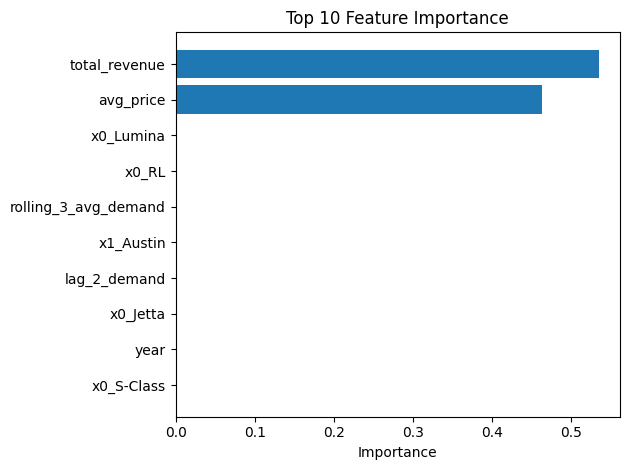


Future Demand Predictions
----------------------------------------
    year_month          model dealer_region body_style transmission  \
198 2022-02-01     Pathfinder        Aurora  Hatchback         Auto   
198 2022-03-01     Pathfinder        Aurora  Hatchback         Auto   
198 2022-04-01     Pathfinder        Aurora  Hatchback         Auto   
161 2022-02-01         Malibu    Greenville  Hatchback       Manual   
161 2022-03-01         Malibu    Greenville  Hatchback       Manual   
161 2022-04-01         Malibu    Greenville  Hatchback       Manual   
159 2022-02-01        M-Class    Greenville  Hatchback       Manual   
159 2022-03-01        M-Class    Greenville  Hatchback       Manual   
159 2022-04-01        M-Class    Greenville  Hatchback       Manual   
180 2022-02-01        Mustang    Middletown  Hatchback       Manual   
180 2022-03-01        Mustang    Middletown  Hatchback       Manual   
180 2022-04-01        Mustang    Middletown  Hatchback       Manual   
174 2022-

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# Predictive Demand Model for Car Sales / Executive Dashboard
# ------------------------------------------------------------
# What this does:
# 1. Loads the car sales dataset
# 2. Creates a monthly demand target (cars sold)
# 3. Engineers time-based and business features
# 4. Trains a Random Forest model to predict demand
# 5. Evaluates model performance
# 6. Predicts future monthly demand
#
# Update FILE_PATH to match your dataset location.
# ------------------------------------------------------------

FILE_PATH = "car_sales cleaned with dashboard.xlsx"  # change this if needed


def load_data(file_path: str) -> pd.DataFrame:
    """Load dataset and standardize column names."""
    df = pd.read_excel(file_path)
    df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]
    return df


def find_date_column(df: pd.DataFrame) -> str:
    """Try to detect the sales date column."""
    possible_date_cols = [
        "date",
        "sale_date",
        "sales_date",
        "order_date",
        "transaction_date",
    ]

    for col in possible_date_cols:
        if col in df.columns:
            return col

    raise ValueError(
        "No date column found. Expected one of: "
        f"{possible_date_cols}. Available columns: {list(df.columns)}"
    )


def find_price_column(df: pd.DataFrame) -> str:
    """Try to detect a price/sales amount column."""
    possible_price_cols = [
        "price",
        "selling_price",
        "sale_price",
        "sales",
        "amount",
        "revenue",
        "price_($)"
    ]

    for col in possible_price_cols:
        if col in df.columns:
            return col

    raise ValueError(
        "No price column found. Expected one of: "
        f"{possible_price_cols}. Available columns: {list(df.columns)}"
    )


def prepare_monthly_demand_data(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate raw sales into monthly demand observations."""
    date_col = find_date_column(df)
    price_col = find_price_column(df)

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col]).copy()

    # Optional business columns if they exist
    model_col = "model" if "model" in df.columns else None
    region_col = "dealer_region" if "dealer_region" in df.columns else None
    body_style_col = "body_style" if "body_style" in df.columns else None
    transmission_col = "transmission" if "transmission" in df.columns else None
    color_col = "color" if "color" in df.columns else None

    df["year_month"] = df[date_col].dt.to_period("M").dt.to_timestamp()

    group_cols = ["year_month"]
    for col in [model_col, region_col, body_style_col, transmission_col, color_col]:
        if col:
            group_cols.append(col)

    monthly = (
        df.groupby(group_cols)
        .agg(
            demand=(price_col, "size"),
            avg_price=(price_col, "mean"),
            total_revenue=(price_col, "sum"),
        )
        .reset_index()
    )

    # Time-based features
    monthly["year"] = monthly["year_month"].dt.year
    monthly["month"] = monthly["year_month"].dt.month
    monthly["quarter"] = monthly["year_month"].dt.quarter
    monthly["is_year_end"] = monthly["month"].isin([11, 12]).astype(int)
    monthly["is_summer"] = monthly["month"].isin([6, 7, 8]).astype(int)

    # Lag features by product/region segment when available
    lag_group_cols = []
    for col in [model_col, region_col, body_style_col, transmission_col, color_col]:
        if col:
            lag_group_cols.append(col)

    monthly = monthly.sort_values(group_cols)

    if lag_group_cols:
        monthly["lag_1_demand"] = monthly.groupby(lag_group_cols)["demand"].shift(1)
        monthly["lag_2_demand"] = monthly.groupby(lag_group_cols)["demand"].shift(2)
        monthly["rolling_3_avg_demand"] = (
            monthly.groupby(lag_group_cols)["demand"]
            .shift(1)
            .rolling(3)
            .mean()
        )
    else:
        monthly["lag_1_demand"] = monthly["demand"].shift(1)
        monthly["lag_2_demand"] = monthly["demand"].shift(2)
        monthly["rolling_3_avg_demand"] = monthly["demand"].shift(1).rolling(3).mean()

    return monthly


def build_model(df_monthly: pd.DataFrame):
    """Train the predictive demand model."""
    target = "demand"

    feature_cols = [col for col in df_monthly.columns if col not in ["demand", "year_month"]]
    X = df_monthly[feature_cols]
    y = df_monthly[target]

    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()

    numeric_transformer = Pipeline(
        steps=[("imputer", SimpleImputer(strategy="median"))]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols),
        ]
    )

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("\nModel Performance")
    print("-" * 40)
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.4f}")

    results = pd.DataFrame({
        "actual_demand": y_test.values,
        "predicted_demand": np.round(y_pred, 2),
    })

    print("\nSample Predictions vs Actual")
    print("-" * 40)
    print(results.head(10))

    return pipeline, feature_cols


def make_future_predictions(df_monthly: pd.DataFrame, pipeline, periods: int = 3) -> pd.DataFrame:
    """Create simple future demand predictions using the latest month for each segment."""
    latest_rows = df_monthly.sort_values("year_month").groupby(
        [col for col in df_monthly.columns if col in ["model", "dealer_region", "body_style", "transmission", "color"]],
        dropna=False,
        as_index=False,
    ).tail(1) if any(col in df_monthly.columns for col in ["model", "dealer_region", "body_style", "transmission", "color"]) else df_monthly.sort_values("year_month").tail(1)

    future_records = []

    for _, row in latest_rows.iterrows():
        current = row.copy()
        last_date = current["year_month"]

        for step in range(1, periods + 1):
            future_date = last_date + pd.DateOffset(months=step)
            new_row = current.copy()
            new_row["year_month"] = future_date
            new_row["year"] = future_date.year
            new_row["month"] = future_date.month
            new_row["quarter"] = future_date.quarter
            new_row["is_year_end"] = int(future_date.month in [11, 12])
            new_row["is_summer"] = int(future_date.month in [6, 7, 8])

            # Keep latest known lag-style values as placeholders for future forecasting
            future_records.append(new_row)

    future_df = pd.DataFrame(future_records)
    X_future = future_df[[col for col in future_df.columns if col not in ["demand", "year_month"]]]
    future_df["predicted_demand"] = np.round(pipeline.predict(X_future), 2)

    cols_to_show = [col for col in ["year_month", "model", "dealer_region", "body_style", "transmission", "predicted_demand"] if col in future_df.columns]
    if "predicted_demand" not in cols_to_show:
        cols_to_show.append("predicted_demand")

    return future_df[cols_to_show]


import matplotlib.pyplot as plt


def plot_predictions(monthly_df, future_df):
    """Create predictive charts for demand forecasting."""
    plt.figure()

    # Historical demand (aggregate)
    hist = monthly_df.groupby("year_month")["demand"].sum().reset_index()
    plt.plot(hist["year_month"], hist["demand"], label="Historical Demand")

    # Future predictions (aggregate)
    if "year_month" in future_df.columns:
        future = future_df.groupby("year_month")["predicted_demand"].sum().reset_index()
        plt.plot(future["year_month"], future["predicted_demand"], linestyle="--", label="Predicted Demand")

    plt.xlabel("Date")
    plt.ylabel("Demand (Units Sold)")
    plt.title("Demand Forecast (Historical vs Predicted)")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(pipeline, feature_names):
    """Plot feature importance from Random Forest."""
    model = pipeline.named_steps["model"]
    importances = model.feature_importances_

    # Get transformed feature names
    try:
        ohe = pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
        cat_features = ohe.get_feature_names_out()
    except:
        cat_features = []

    num_features = pipeline.named_steps["preprocessor"].transformers_[0][2]
    all_features = list(num_features) + list(cat_features)

    importance_df = pd.DataFrame({
        "feature": all_features,
        "importance": importances
    }).sort_values(by="importance", ascending=False).head(10)

    plt.figure()
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.xlabel("Importance")
    plt.title("Top 10 Feature Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


def main():
    df = load_data(FILE_PATH)
    monthly_df = prepare_monthly_demand_data(df)

    print("\nPrepared Monthly Demand Data")
    print("-" * 40)
    print(monthly_df.head())

    model_pipeline, feature_cols = build_model(monthly_df)

    print("\nModel Features Used")
    print("-" * 40)
    print(feature_cols)

    future_predictions = make_future_predictions(monthly_df, model_pipeline, periods=3)

    # -----------------------------
    # PLOTS (Predictive Charts)
    # -----------------------------
    plot_predictions(monthly_df, future_predictions)
    plot_feature_importance(model_pipeline, feature_cols)

    print("\nFuture Demand Predictions")
    print("-" * 40)
    print(future_predictions.head(20))

    future_predictions.to_csv("future_demand_predictions.csv", index=False)
    print("\nSaved predictions to future_demand_predictions.csv")


if __name__ == "__main__":
    main()
